In [1]:
import numpy as np 
import pyvista 
from tqdm import tqdm 
import glob 
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import griddata 

import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000000000000000000
import matplotlib.pyplot as plt 
from matplotlib.cm import ScalarMappable
plt.tight_layout()


<Figure size 640x480 with 0 Axes>

In [2]:
filelist = glob.glob('data/*/*.pvd')

scenarios = []

times = {}
rawdata = {} 
for filepath in np.sort(filelist): 
    
    filename = filepath.split("/")[-1]
    print(filename)

    scenario = int(filename[8])
    scenarios.append(scenario)
    rawdata[scenario] = {}

    reader = pyvista.get_reader(filepath)
    points = reader.read().get(0).points 
    x = points[:,0]
    y = points[:,1]

    rawdata[scenario]['x'] = x
    rawdata[scenario]['y'] = y

    times[scenario] = []

    for time in reader.time_values: 
        times[scenario].append(time)
        reader.set_active_time_value(time)
        rawdata[scenario][time] = np.asarray(reader.read().get(0).get_array("u"))

    rawdata[scenario]["alpha"] = np.asarray(reader.read().get(0).get_array("alpha"))
    times[scenario] = list(set(times[scenario]))

scenarios = list(set(scenarios))

print(scenarios)
print(times)

Marmousi0_c_0.200000.pvd
Marmousi1_c_0.200000.pvd
Marmousi2_c_0.200000.pvd
[0, 1, 2]
{0: [1.0, 2.0, 3.0], 1: [1.0, 2.0, 3.0], 2: [0.3, 1.0, 1.5, 2.0, 3.0, 0.01, 0.02]}


In [3]:
data = {}
xi = np.linspace(0,1,1001)
yi = np.linspace(0,1,1001)
data['X'], data['Y'] = np.meshgrid(xi, yi)

for sc in scenarios: 
    print(sc)
    data[sc] = {}
    for time in times[sc]:
        print(time) 
        data[sc][time] = griddata((x, y), rawdata[sc][time], (data['X'], data['Y']), method='linear')
    print('alpha')
    data[sc]['alpha'] = griddata((x, y), rawdata[sc]["alpha"], (data['X'], data['Y']), method='linear')

0
1.0
2.0
3.0
alpha
1
1.0
2.0
3.0
alpha
2
0.3
1.0
1.5
2.0
3.0
0.01
0.02
alpha


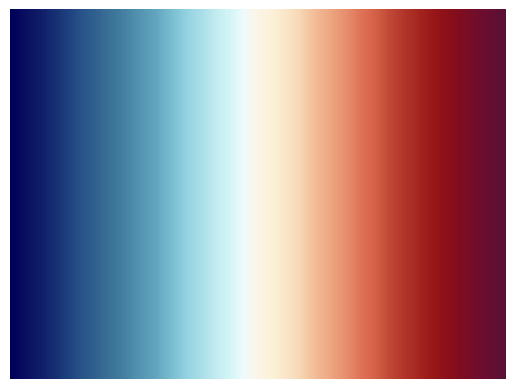

In [4]:
cooltowarmcolors = [
    (0.000000, 0.000000, 0.349020), 
    (0.039216, 0.062745, 0.380392), 
    (0.062745, 0.117647, 0.411765), 
    (0.090196, 0.184314, 0.450980), 
    (0.125490, 0.262745, 0.501961), 
    (0.160784, 0.337255, 0.541176), 
    (0.200000, 0.396078, 0.568627),      
    (0.239216, 0.454902, 0.600000),
    (0.286275, 0.521569, 0.650980),
    (0.337255, 0.592157, 0.701961),
    (0.388235, 0.654902, 0.749020),
    (0.466667, 0.737255, 0.819608),
    (0.572549, 0.819608, 0.878431),
    (0.654902, 0.866667, 0.909804),
    (0.752941, 0.917647, 0.941176),
    (0.823529, 0.956863, 0.968627),
    (0.941176, 0.984314, 0.988235),
    (0.988235, 0.960784, 0.901961),
    (0.988235, 0.945098, 0.850980),
    (0.980392, 0.898039, 0.784314),
    (0.968627, 0.835294, 0.698039),
    (0.949020, 0.733333, 0.588235),
    (0.929412, 0.650980, 0.509804),
    (0.909804, 0.564706, 0.435294),
    (0.878431, 0.458824, 0.352941),
    (0.839216, 0.388235, 0.286275),
    (0.760784, 0.294118, 0.211765),
    (0.701961, 0.211765, 0.168627),
    (0.650980, 0.156863, 0.129412),
    (0.600000, 0.094118, 0.094118),
    (0.549020, 0.066667, 0.098039),
    (0.501961, 0.050980, 0.125490),
    (0.450980, 0.052902, 0.172549),
    (0.400000, 0.054902, 0.192157),
    (0.349020, 0.070588, 0.211765)
]

# Create sample colormaps for demo
cooltowarmcmap = LinearSegmentedColormap.from_list("cooltowarm", cooltowarmcolors)

gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.imshow(gradient, aspect='auto', cmap=cooltowarmcmap)
plt.axis('off')
plt.show()

/tmp/ipykernel_349416/2006807136.py:8: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.savefig("Compression_cbar_t2.pdf", bbox_inches="tight")
/home/jonas/.local/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/home/jonas/.local/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


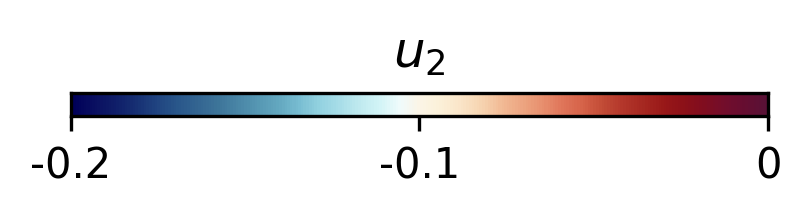

In [5]:
fig, ax = plt.subplots(1,1,figsize = (6./2.,0.1),  dpi=300,constrained_layout=True)
gradient = np.linspace(0, 1, 301).reshape(1, -1)
ax.imshow(gradient, aspect='auto', cmap=cooltowarmcmap)
ax.set_yticks([])
ax.set_xticks([-1,150,301])
ax.set_xticklabels([-0.2,-0.1,0])
ax.set_title(r"$u_2$")
fig.savefig("Compression_cbar_t2.pdf", bbox_inches="tight")

/tmp/ipykernel_349416/3034408676.py:8: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.savefig("Compression_cbar_t2_5.pdf", bbox_inches="tight")
/home/jonas/.local/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/home/jonas/.local/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


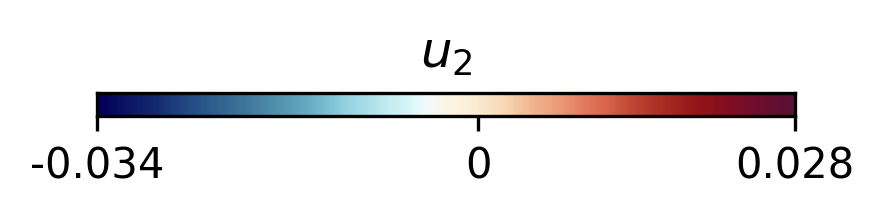

In [6]:
fig, ax = plt.subplots(1,1,figsize = (6./2.,0.1),  dpi=300,constrained_layout=True)
gradient = np.linspace(0, 1, 301).reshape(1, -1)
ax.imshow(gradient, aspect='auto', cmap=cooltowarmcmap)
ax.set_yticks([])
ax.set_xticks([-1,164,301])
ax.set_xticklabels([-0.034,0,0.028])
ax.set_title(r"$u_2$")
fig.savefig("Compression_cbar_t2_5.pdf", bbox_inches="tight")

/tmp/ipykernel_349416/2795605373.py:8: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.savefig("Compression_cbar_t2_5.pdf", bbox_inches="tight")
/home/jonas/.local/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/home/jonas/.local/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


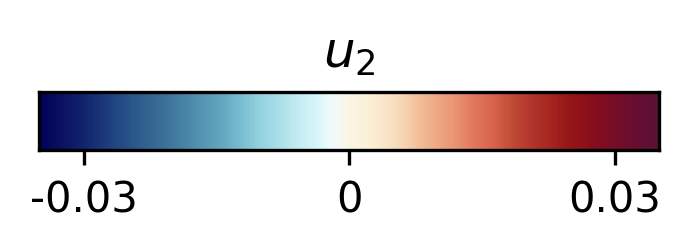

In [7]:
fig, ax = plt.subplots(1,1,figsize = (8./3.,0.25),  dpi=300,constrained_layout=True)
gradient = np.linspace(0, 1, 701).reshape(1, -1)
ax.imshow(gradient, aspect='auto', cmap=cooltowarmcmap)
ax.set_yticks([])
ax.set_xticks([50,350,650])
ax.set_xticklabels([-0.03,0,0.03])
ax.set_title(r"$u_2$")
fig.savefig("Compression_cbar_t2_5.pdf", bbox_inches="tight")

In [8]:
for sc in [0,1,2]: 
    print(sc, np.min(data[sc]['alpha']), np.max(data[sc]['alpha']))

vmin = {}
vmax = {}
vabs = {}
for time in ['alpha', 1.0,2.0,3.0]: 
    vmin[time] = np.min([np.min(data[0][time]), np.min(data[1][time]), np.min(data[2][time])])
    vmax[time] = np.max([np.max(data[0][time]), np.max(data[1][time]), np.max(data[2][time])])
    vabs[time] = np.max([np.abs(vmin[time]), np.abs(vmax[time])])
    print(vmin[time], vmax[time], vabs[time])



0 0.5372687499999985 2.4349395581054694
1 0.5 2.5
2 0.4999999999999999 2.500000000000001
0.4999999999999999 2.500000000000001 2.500000000000001
-1.0494124929606312 0.6733867936942618 1.0494124929606312
-8.451691322934575 7.766569634112385 8.451691322934575
-185.9852159478016 256.46216437503216 256.46216437503216


In [10]:
mpl.rcParams['agg.path.chunksize'] = 10000000000000000000

fig = mpl.pyplot.figure(figsize = (12,12), dpi=300)

gap = 0.02 
width = 0.225 
cb_gap = 0.02

cmaps = {}
cmaps['alpha'] = 'cividis'
cmaps[1.0] = cooltowarmcmap
cmaps[2.0] = cooltowarmcmap
cmaps[3.0] = cooltowarmcmap

titles = {}
titles['alpha'] = r"$c_\alpha$"
titles[1.0] = r"$t = 1$"
titles[2.0] = r"$t = 2$"
titles[3.0] = r"$t = 3$"

cbtitles = {}
cbtitles['alpha'] = r"$c_\alpha$"
cbtitles[1.0] = r"$t = 1$"
cbtitles[2.0] = r"$t = 2$"
cbtitles[3.0] = r"$t = 3$"

ax = {}
ax['colorbar'] = {}
for idt, time in enumerate(['alpha'] + times): 
    ax['colorbar'][time] = fig.add_axes([0.05 + gap + cb_gap + (idt) * (gap + width), gap, width - 2*cb_gap, 0.04])   
    ax['colorbar'][time].set_xticks([]) 
    ax['colorbar'][time].set_yticks([]) 

for sc in [0,1,2]: 
    ax[sc] = {}
    for idt, time in enumerate(['alpha'] + times): 
        ax[sc][time] = fig.add_axes([0.05 + gap + (idt) * (gap + width), 0.08 + sc * (gap+width), width, width])    
        ax[sc][time].set_xticks([]) 
        ax[sc][time].set_yticks([]) 
        ax[sc][time].set_aspect('equal')

cnt = {} 
for sc in [0,1,2]: 
    cnt[sc] = {}
    for time in (['alpha'] + times):  
        cnt[sc][time] = ax[sc][time].imshow(data[sc][time][::-1], cmap = cmaps[time], vmin=vmin[time], vmax=vmax[time])

for time in (['alpha'] + times):  
    norm = mpl.colors.Normalize(vmin=vmin[time], vmax=vmax[time])
    sm = ScalarMappable(norm=norm, cmap=cmaps[time])
    sm.set_array([])  # Dummy data to satisfy colorbar
    cbar = fig.colorbar(sm, cax=ax['colorbar'][time], orientation='horizontal')
    cbar.ax.tick_params(labelsize=14)

for time in (['alpha'] + times):  
    ax['colorbar'][time].set_title(cbtitles[time], fontsize=14)
    ax[2][time].set_title(titles[time], fontsize=14)

# fig.savefig("SpaceDependentMarmousi.png", bbox_inches='tight', pad_inches=0.3)
# fig.savefig("SpaceDependentMarmousi.pdf", bbox_inches='tight', pad_inches=0.3)


TypeError: can only concatenate list (not "dict") to list

<Figure size 3600x3600 with 0 Axes>

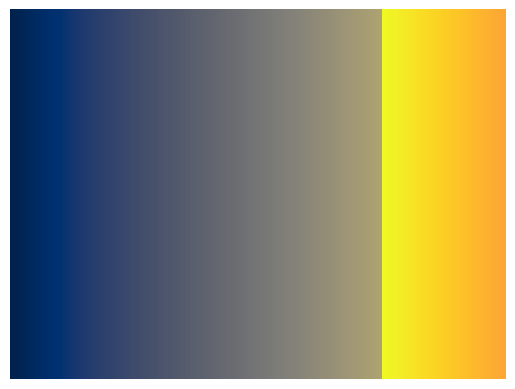

In [11]:
cmap1 = mpl.colormaps['cividis']    # for range 0.5 to 2
cmap2 = mpl.colormaps['plasma']     # for range 2 to 2.5

N1 = int(0.75 * 256)
N2 = 256 - N1
twocolors = np.vstack([
    cmap1(np.linspace(0., 0.7, N1)),
    cmap2(np.linspace(0.8, 1, N2)[::-1])
])
twocolorsmap = LinearSegmentedColormap.from_list("twocolorsmap", twocolors)

gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.imshow(gradient, aspect='auto', cmap=twocolorsmap)
plt.axis('off')
plt.show()

<Figure size 640x480 with 0 Axes>

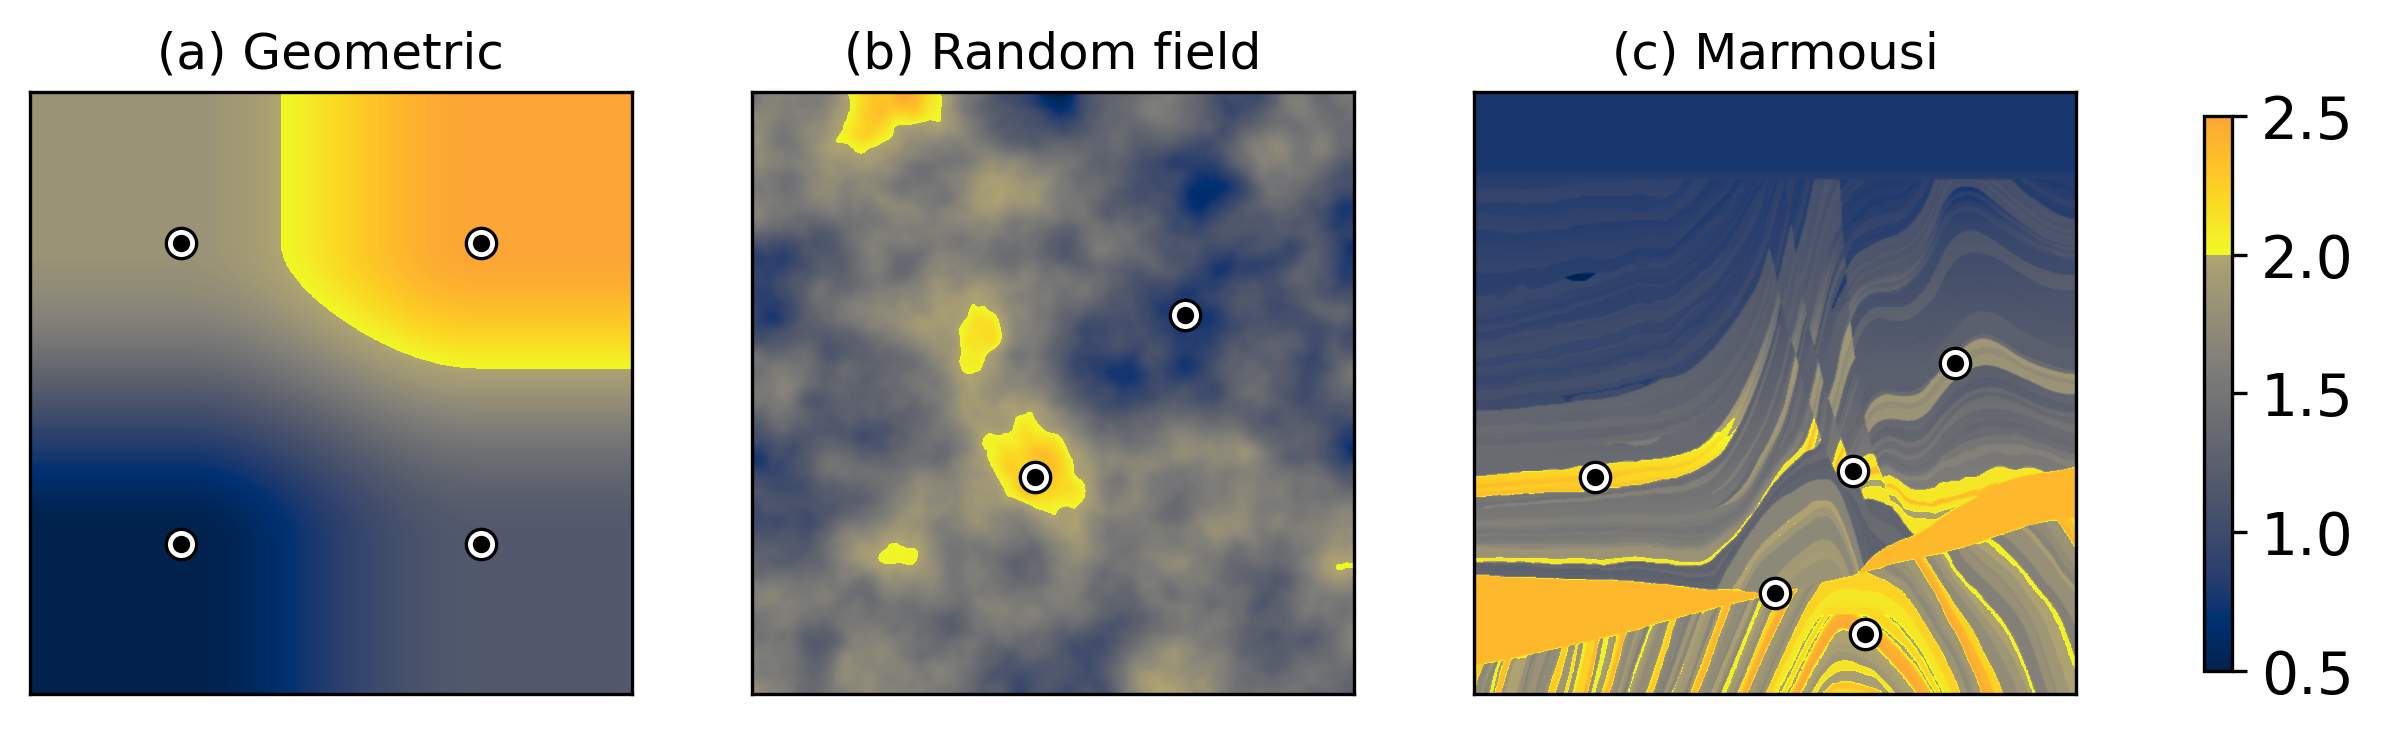

In [12]:
mpl.rcParams['agg.path.chunksize'] = 10000000000000000000
plt.tight_layout()
fig, ax = plt.subplots(1,3,figsize = (11,4), dpi=300)

cnt = {} 
for sc in [0,1,2]:  
    cnt[sc] = ax[2-sc].imshow(data[sc]['alpha'][::-1], cmap = twocolorsmap) 
    ax[2-sc].set_xticks([]) 
    ax[2-sc].set_yticks([]) 
    ax[2-sc].set_aspect("equal")

norm = mpl.colors.Normalize(vmin=0.5, vmax=2.5)
sm = ScalarMappable(norm=norm, cmap=twocolorsmap)
sm.set_array([])  # Dummy data to satisfy colorbar
cbar = fig.colorbar(sm, ax=ax[:], orientation='vertical', shrink=0.6)
cbar.ax.tick_params(labelsize=14)

for size,color in zip([50,30,10], ["black", "white", "black"]): 
    ax[0].scatter(250,250, s=size, marker='o', color =color)
    ax[0].scatter(250,750, s=size, marker='o', color =color)
    ax[0].scatter(750,250, s=size, marker='o', color =color)
    ax[0].scatter(750,750, s=size, marker='o', color =color)

    ax[1].scatter(470,1000-360, s=size, marker='o', color =color)
    ax[1].scatter(720,1000-630, s=size, marker='o', color =color)

    ax[2].scatter(630,1000-370, s=size, marker='o', color =color)
    ax[2].scatter(500,1000-167, s=size, marker='o', color =color)
    ax[2].scatter(650,1000-100, s=size, marker='o', color =color)
    ax[2].scatter(800,1000-550, s=size, marker='o', color =color)
    ax[2].scatter(200,1000-360, s=size, marker='o', color =color)

ax[0].set_title("(a) Geometric")
ax[1].set_title("(b) Random field")
ax[2].set_title("(c) Marmousi")

fig.savefig("SpaceDependentDOWaveAlpha.png", bbox_inches='tight')
fig.savefig("SpaceDependentDOWaveAlpha.pdf", bbox_inches='tight')


In [13]:
from PIL import Image
img = Image.open('SpaceDependentDOWaveAlpha.png').convert('L')  # 'L' = 8-bit greyscale

# Show the greyscale version
img.show()


# 3 in a row

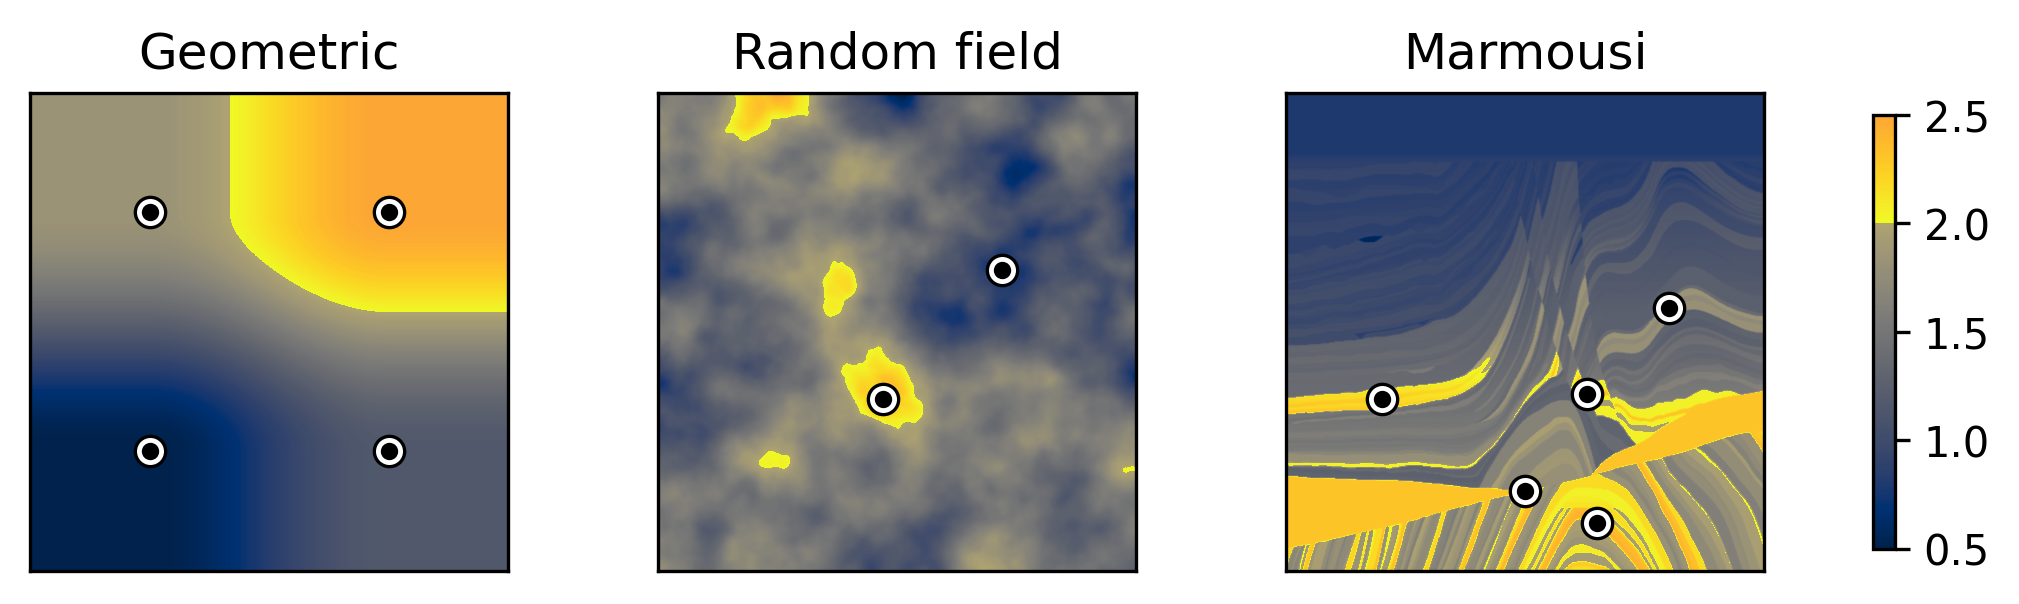

In [14]:
fig, ax = plt.subplots(1,3,figsize = (8,3), dpi=300)
plt.tight_layout()

# plot
norm = mpl.colors.Normalize(vmin=0.5, vmax=2.5)
ax[0].imshow(data[2]['alpha'][::-1], norm=norm, cmap = twocolorsmap) 
ax[1].imshow(data[1]['alpha'][::-1], norm = norm, cmap = twocolorsmap) 
ax[2].imshow(data[0]['alpha'][::-1], norm = norm, cmap = twocolorsmap) 

# cbar 
sm = ScalarMappable(norm=norm, cmap=twocolorsmap)
sm.set_array([])  # Dummy data to satisfy colorbar
cbar = fig.colorbar(sm, ax=ax[:], orientation='vertical', shrink=0.6)
cbar.set_ticks([0.5,1.0,1.5,2.0,2.5], labels=[0.5,1.0,1.5,2.0,2.5])

#########################################################################################

for size,color in zip([50,30,10], ["black", "white", "black"]): 
    ax[0].scatter(250,250, s=size, marker='o', color =color)
    ax[0].scatter(250,750, s=size, marker='o', color =color)
    ax[0].scatter(750,250, s=size, marker='o', color =color)
    ax[0].scatter(750,750, s=size, marker='o', color =color)

    ax[1].scatter(470,1000-360, s=size, marker='o', color =color)
    ax[1].scatter(720,1000-630, s=size, marker='o', color =color)

    ax[2].scatter(630,1000-370, s=size, marker='o', color =color)
    ax[2].scatter(500,1000-167, s=size, marker='o', color =color)
    ax[2].scatter(650,1000-100, s=size, marker='o', color =color)
    ax[2].scatter(800,1000-550, s=size, marker='o', color =color)
    ax[2].scatter(200,1000-360, s=size, marker='o', color =color)
    
for i in range(3): 
    ax[i].set_xticks([]) 
    ax[i].set_yticks([]) 
    ax[i].set_aspect("equal")

ax[0].set_title(r"Geometric")
ax[1].set_title(r"Random field")
ax[2].set_title(r"Marmousi")

fig.savefig("SpaceDependentDOWaveAlpha.png", bbox_inches='tight')
fig.savefig("SpaceDependentDOWaveAlpha.pdf", bbox_inches='tight')

# 3 by 3 

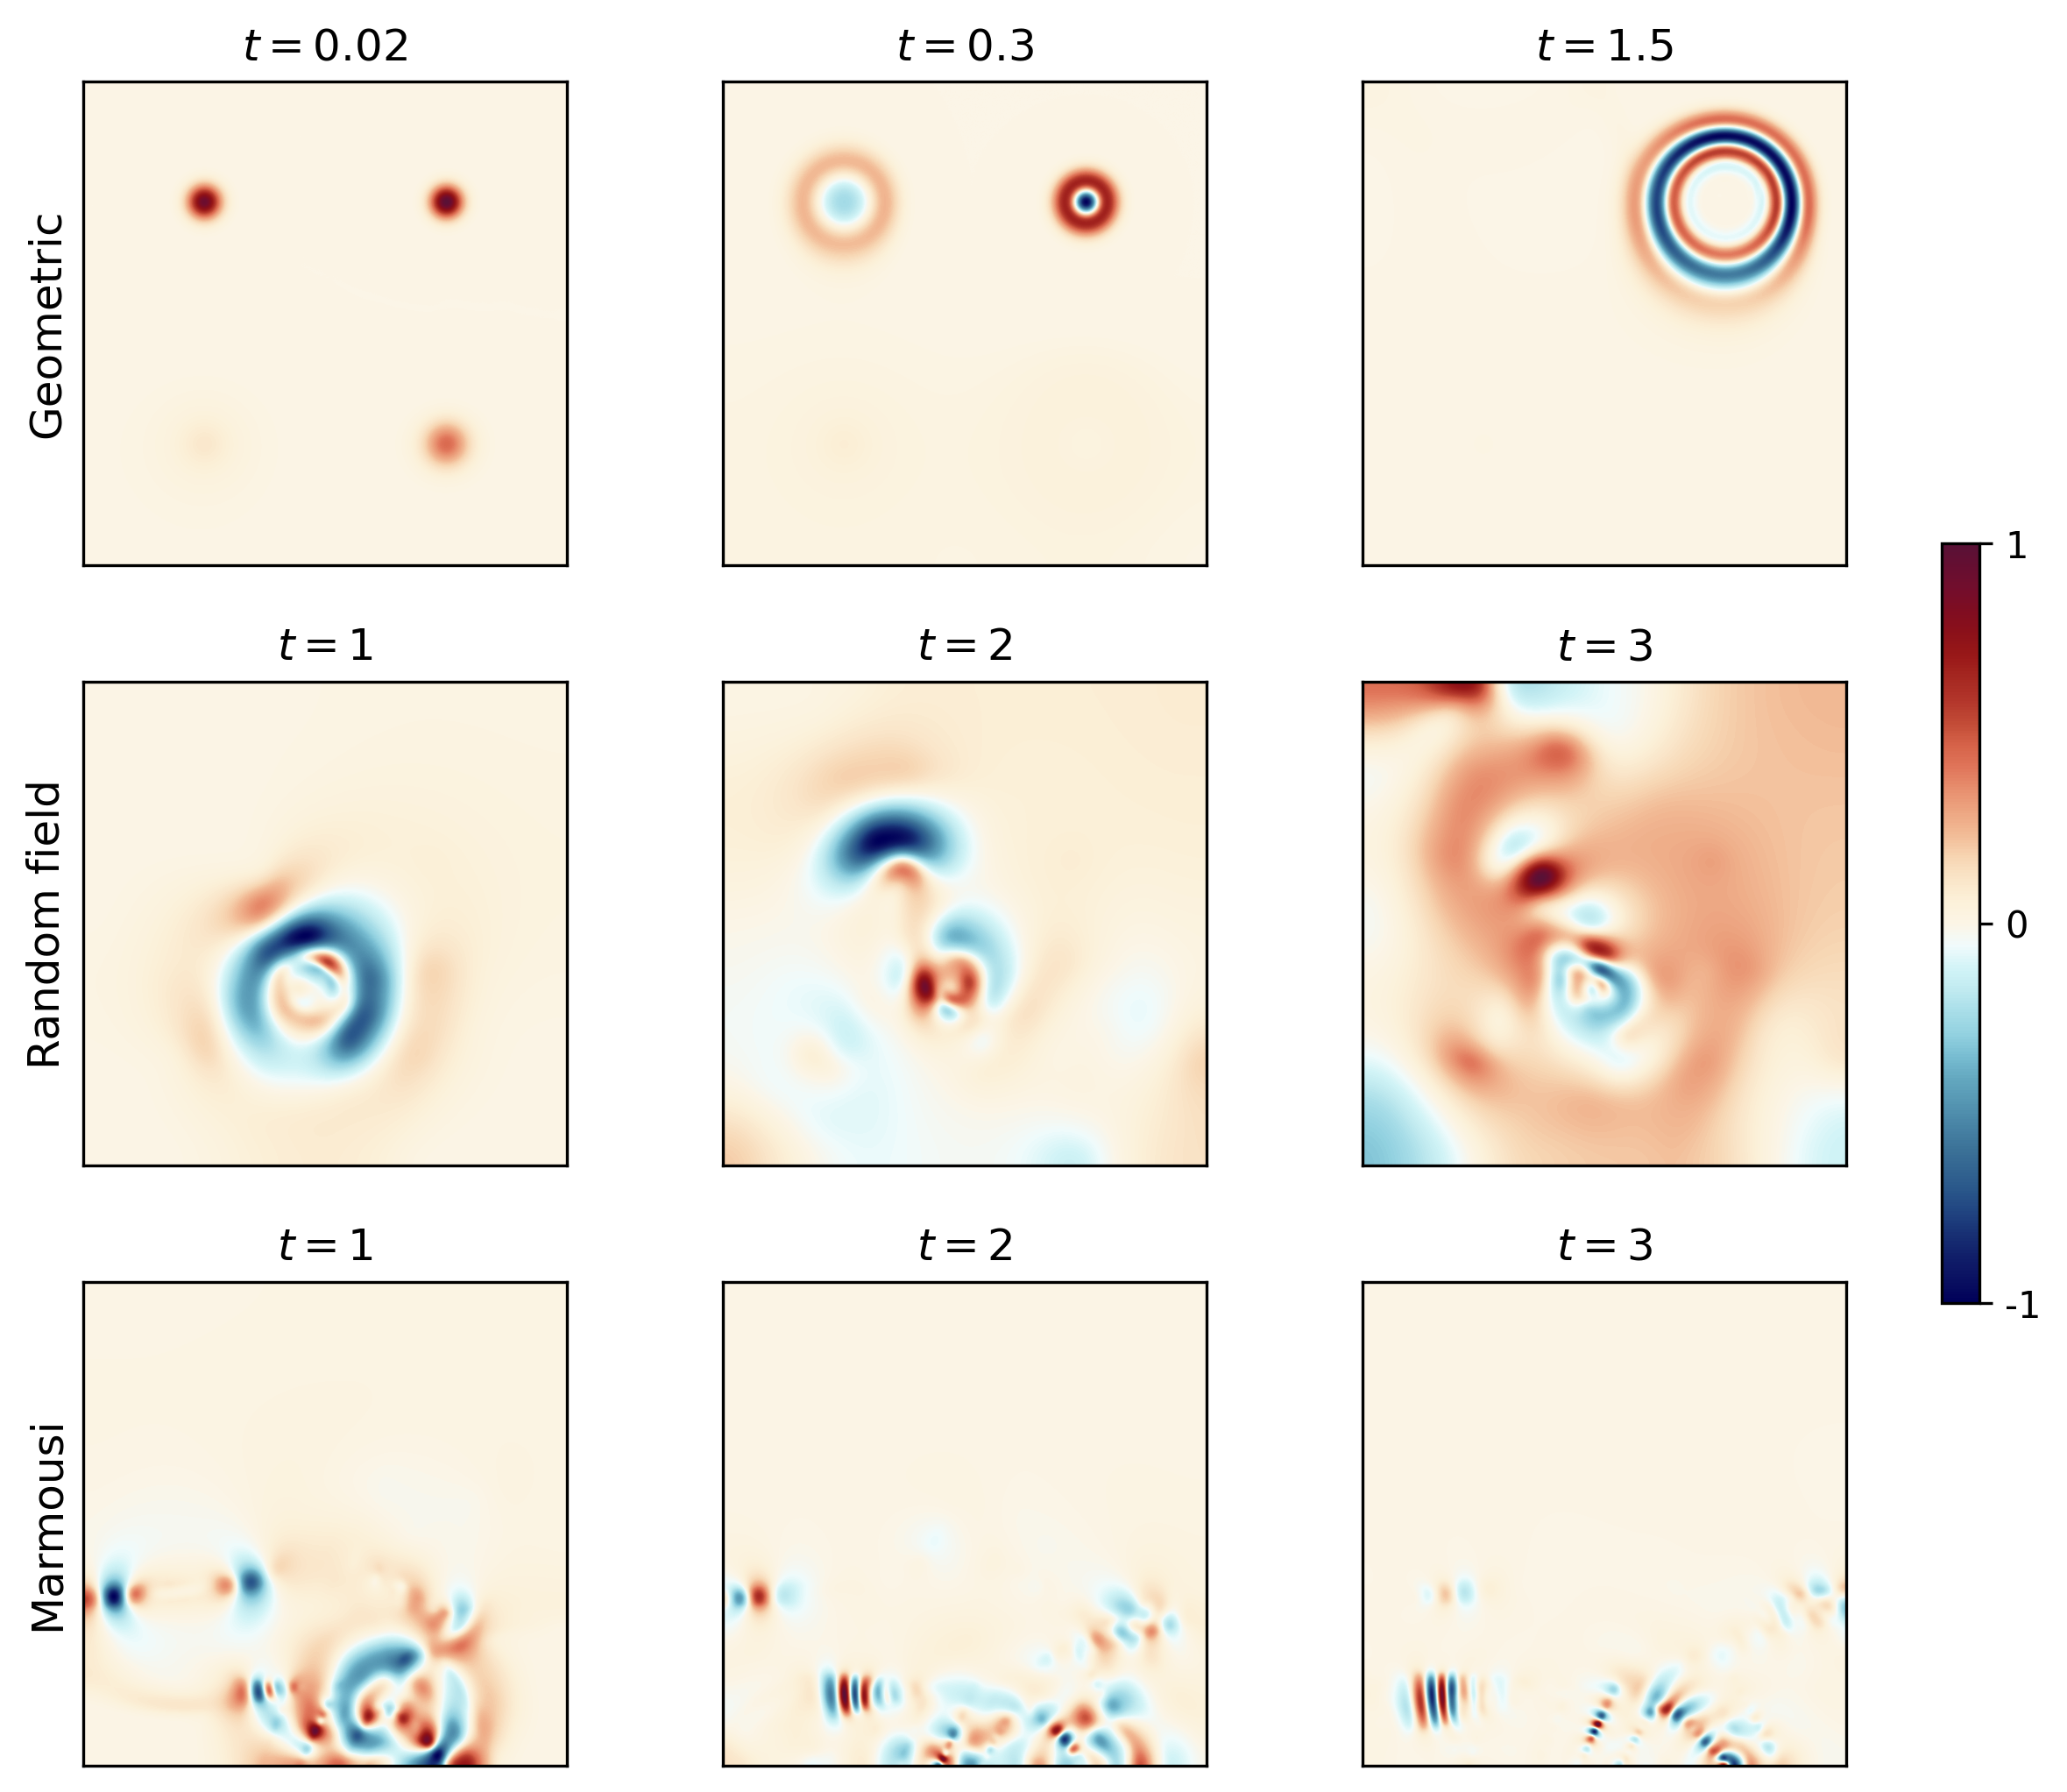

In [15]:
fig, ax = plt.subplots(3,3,figsize = (8,7), dpi=300)
plt.tight_layout()


vabs = max(np.abs(np.min(data[2][0.02])), np.abs(np.max(data[2][0.02])))
norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
ax[0][0].imshow(data[2][0.02][::-1], norm=norm, cmap = cooltowarmcmap) 
vabs = max(np.abs(np.min(data[2][0.3])), np.abs(np.max(data[2][0.3])))
norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
ax[0][1].imshow(data[2][0.3][::-1], norm = norm, cmap = cooltowarmcmap) 
vabs = max(np.abs(np.min(data[2][1.5])), np.abs(np.max(data[2][1.5])))
norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
ax[0][2].imshow(data[2][1.5][::-1], norm = norm, cmap = cooltowarmcmap)

vabs = max(np.abs(np.min(data[1][1])), np.abs(np.max(data[1][1])))
norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
ax[1][0].imshow(data[1][1][::-1], norm=norm, cmap = cooltowarmcmap) 
vabs = max(np.abs(np.min(data[1][2])), np.abs(np.max(data[1][2])))
norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
ax[1][1].imshow(data[1][2][::-1], norm = norm, cmap = cooltowarmcmap) 
vabs = max(np.abs(np.min(data[1][3])), np.abs(np.max(data[1][3])))
norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
ax[1][2].imshow(data[1][3][::-1], norm = norm, cmap = cooltowarmcmap) 


vabs = max(np.abs(np.min(data[0][1])), np.abs(np.max(data[0][1])))
norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
ax[2][0].imshow(data[0][1][::-1], norm=norm, cmap = cooltowarmcmap) 
vabs = max(np.abs(np.min(data[0][2])), np.abs(np.max(data[0][2])))
norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
ax[2][1].imshow(data[0][2][::-1], norm = norm, cmap = cooltowarmcmap) 
vabs = max(np.abs(np.min(data[0][3])), np.abs(np.max(data[0][3])))
norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
ax[2][2].imshow(data[0][3][::-1], norm = norm, cmap = cooltowarmcmap) 

# cbar 
norm = mpl.colors.Normalize(vmin=-1, vmax=1)
sm = ScalarMappable(norm=norm, cmap=cooltowarmcmap)
sm.set_array([])  # Dummy data to satisfy colorbar
cbar = fig.colorbar(sm, ax=ax[:], orientation='vertical', fraction=0.02)
cbar.set_ticks([-1,0,1], labels=[-1,0,1])

#########################################################################################

for i in range(3): 
    for j in range(3): 
        ax[j][i].set_xticks([]) 
        ax[j][i].set_yticks([]) 
        ax[j][i].set_aspect("equal")

ax[0][0].set_title(r"$t=0.02$", size=12)
ax[0][1].set_title(r"$t=0.3$", size=12)
ax[0][2].set_title(r"$t=1.5$", size=12)

ax[1][0].set_title(r"$t=1$", size=12)
ax[1][1].set_title(r"$t=2$", size=12)
ax[1][2].set_title(r"$t=3$", size=12)

ax[2][0].set_title(r"$t=1$", size=12)
ax[2][1].set_title(r"$t=2$", size=12)
ax[2][2].set_title(r"$t=3$", size=12)

ax[0][0].set_ylabel(r"Geometric", size=12)
ax[1][0].set_ylabel(r"Random field", size=12)
ax[2][0].set_ylabel(r"Marmousi", size=12)

fig.savefig("SpaceDependentDOWave3by3.png", bbox_inches='tight')
fig.savefig("SpaceDependentDOWave3by3.pdf", bbox_inches='tight')

# Scenarios as lines

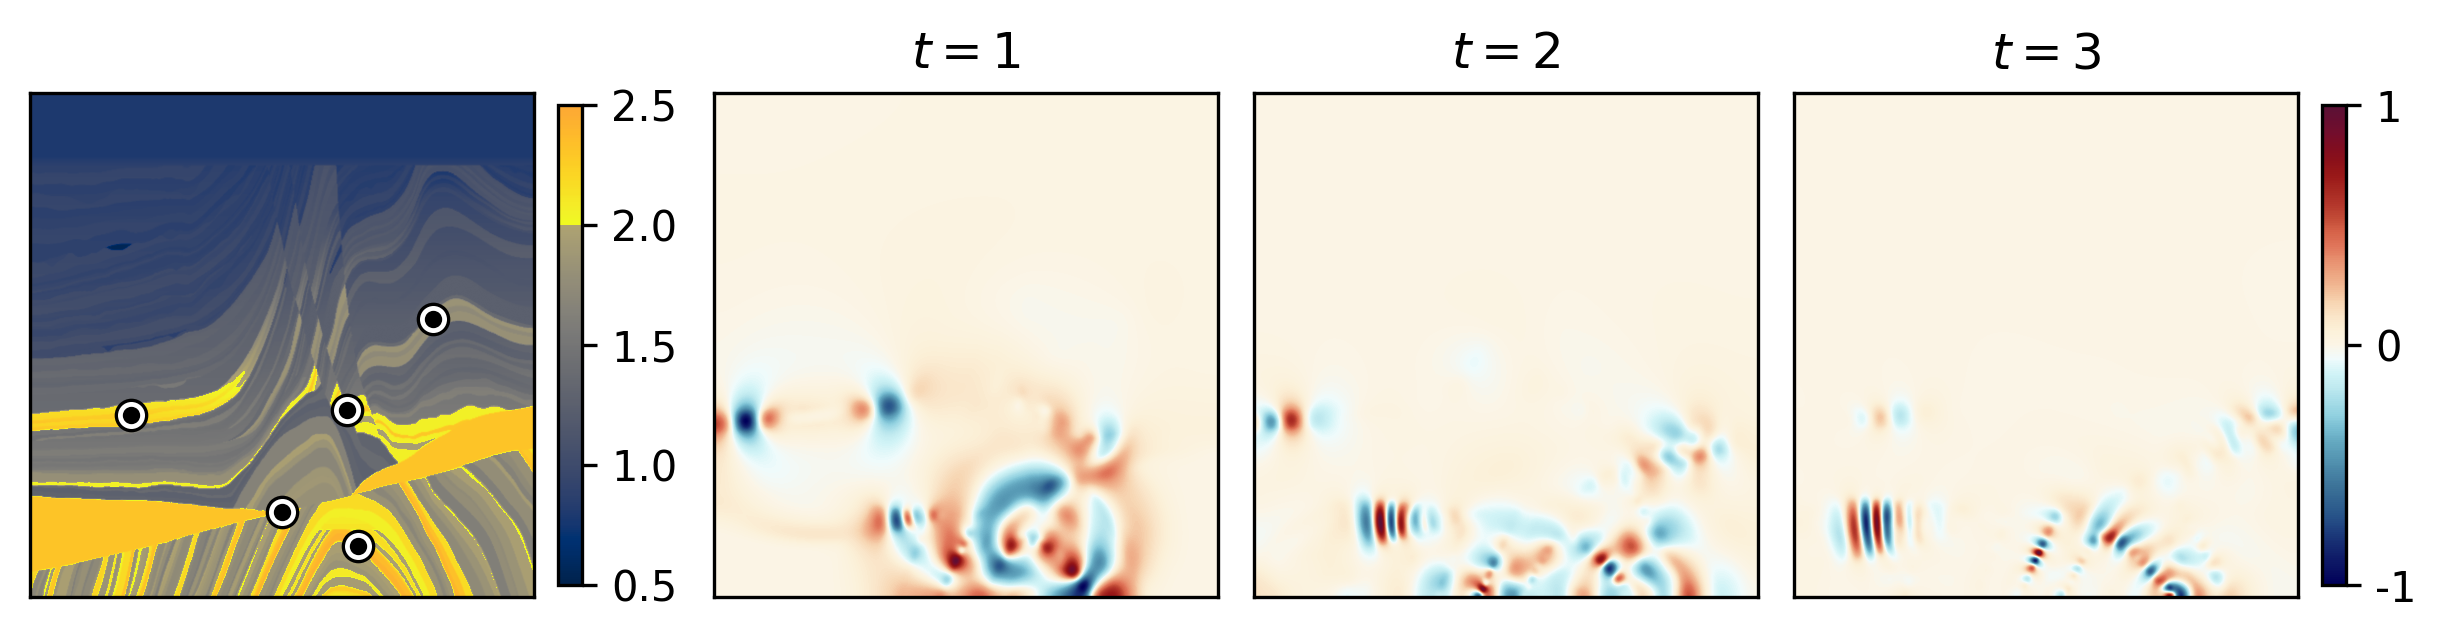

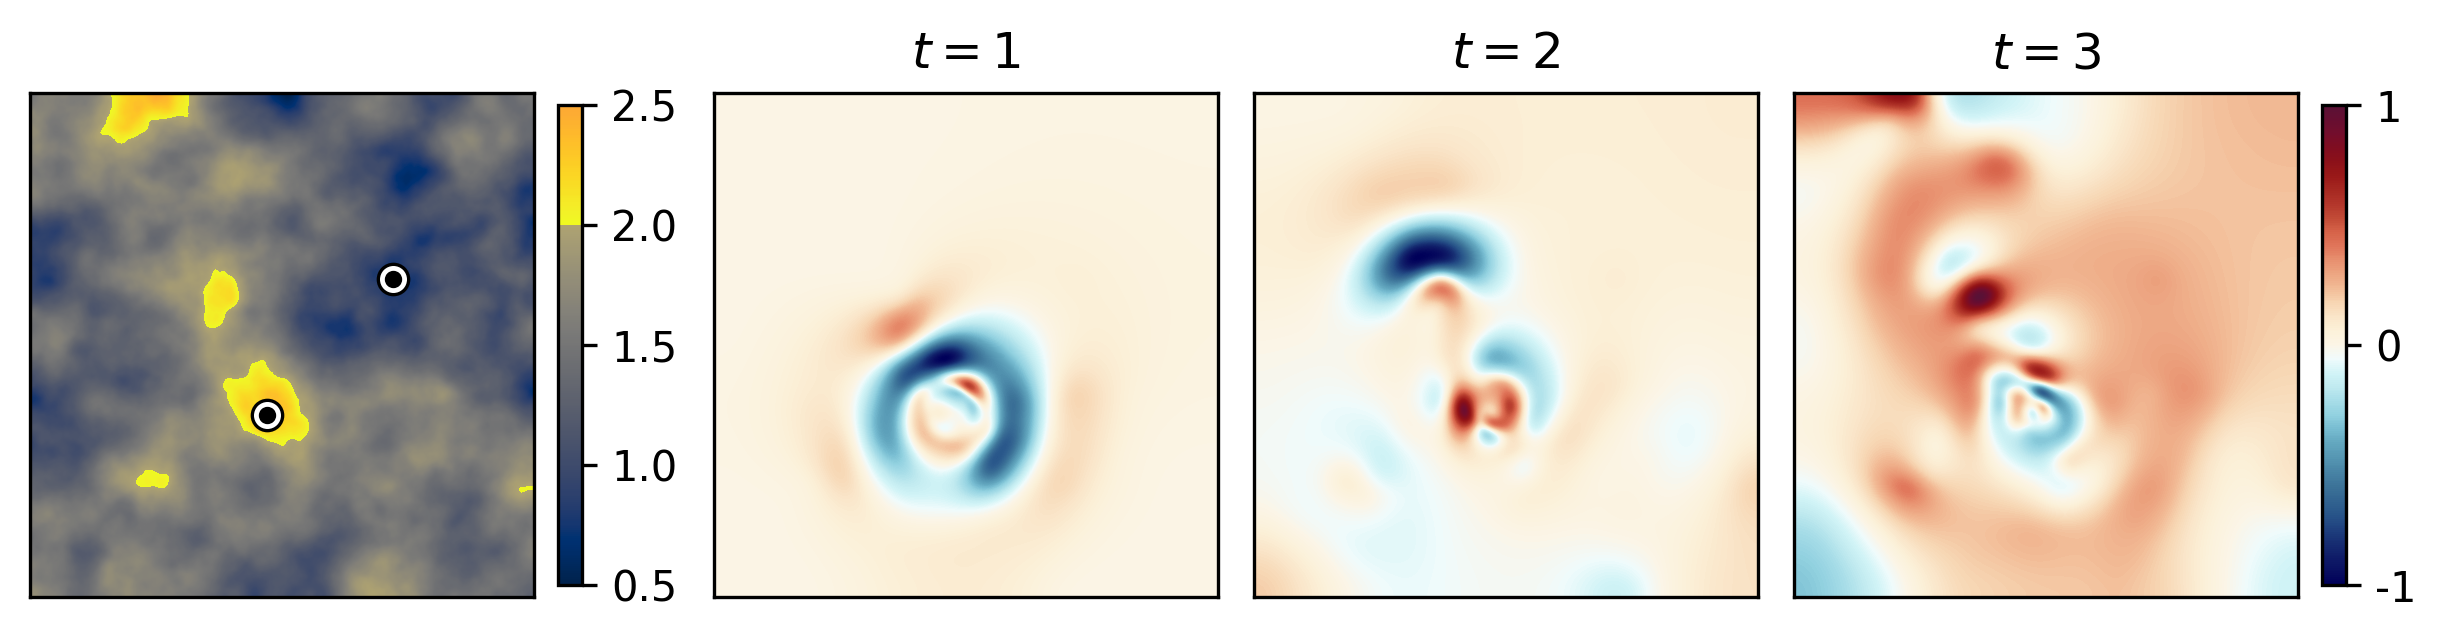

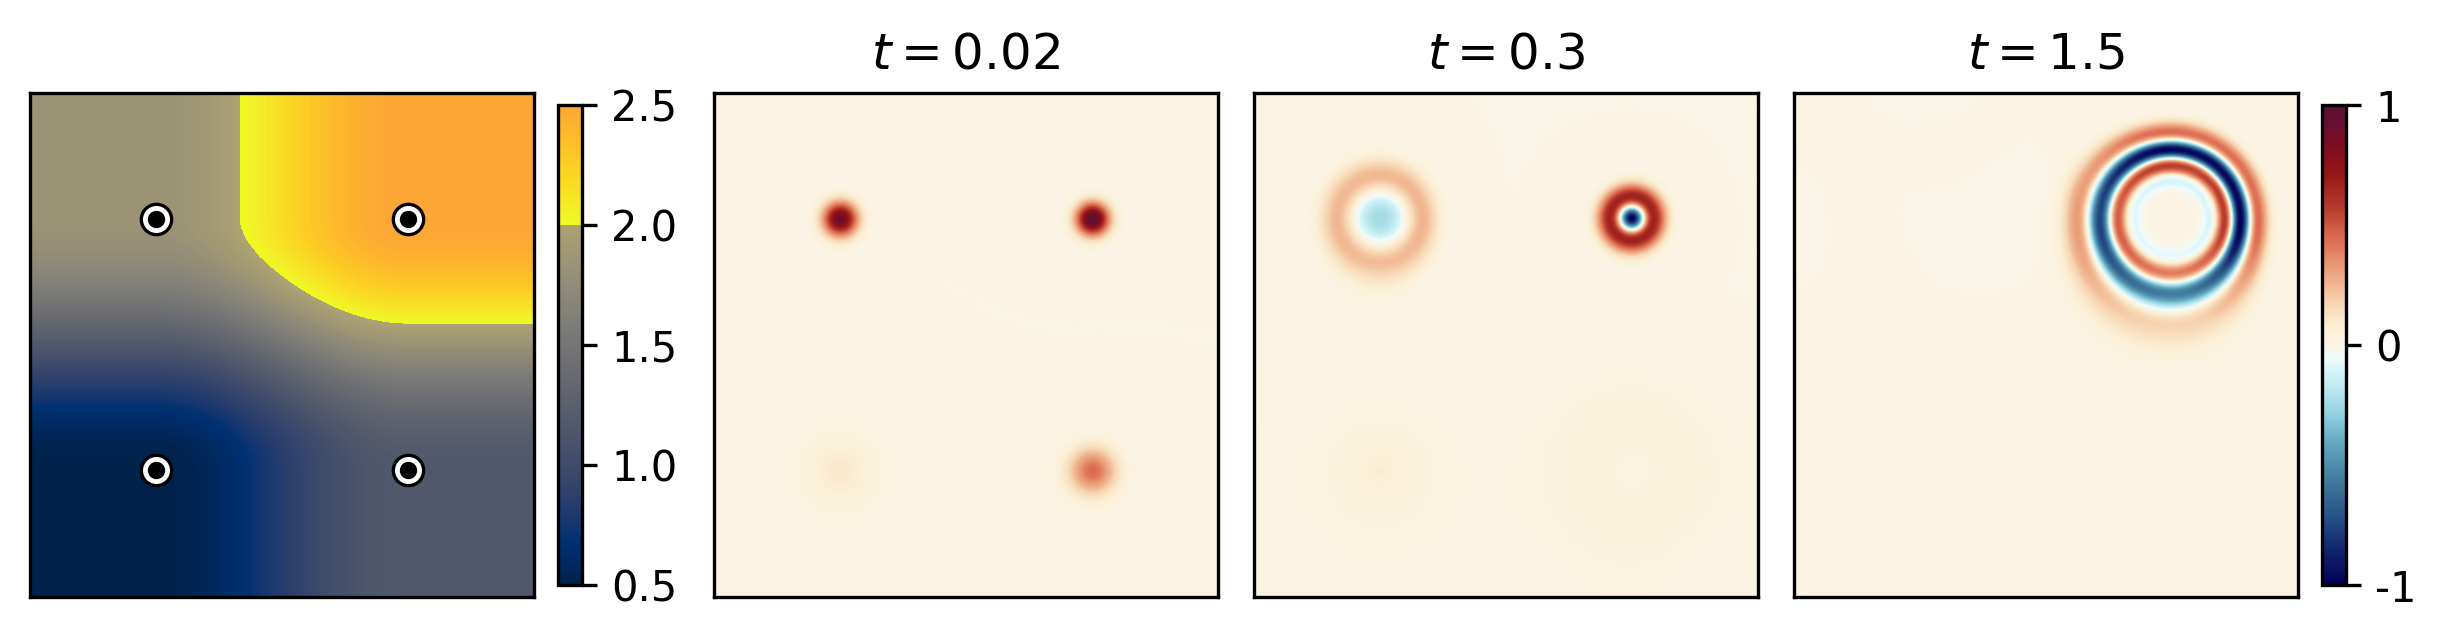

In [88]:
for sc in [0,1,2]: 

    fig = plt.figure(figsize=(8, 2), dpi=300)

    # Positions: [left, bottom, width, height]
    # Very tight layout, no big gaps
    positions = [
        [0.00,  0.0, 0.21,   1.0],  # 1 - square
        [0.22, 0.1, 0.01,  0.8],  # 2 - colorbar
        [0.285, 0.0, 0.21,  1.0],  # 3 - square
        [0.51,   0.0, 0.21,  1.0],  # 4 - square
        [0.735, 0.0, 0.21,  1.0],  # 5 - square
        [0.955,  0.1, 0.01,  0.8],  # 6 - colorbar
    ]

    ax = []
    for i, pos in enumerate(positions, start=1):
        a = fig.add_axes(pos)
        ax.append(a)

    # plot
    norm1 = mpl.colors.Normalize(vmin=0.5, vmax=2.5)
    norm2 = mpl.colors.Normalize(vmin=-1, vmax=1)
    ax[0].imshow(data[sc]['alpha'][::-1], norm=norm1, cmap = twocolorsmap) 
    
    # cbar 1
    sm = ScalarMappable(norm=norm1, cmap=twocolorsmap)
    sm.set_array([])  # Dummy data to satisfy colorbar
    cbar = fig.colorbar(sm, cax=ax[1], orientation='vertical', shrink=0.6)
    cbar.set_ticks([0.5,1.0,1.5,2.0,2.5], labels=[0.5,1.0,1.5,2.0,2.5])

    # cbar 2
    sm = ScalarMappable(norm=norm2, cmap=cooltowarmcmap)
    sm.set_array([])  # Dummy data to satisfy colorbar
    cbar = fig.colorbar(sm, cax=ax[5], orientation='vertical', shrink=0.6)
    cbar.set_ticks([-1,0,1], labels=[-1,0,1])


    ########################################################################################

    for size,color in zip([50,30,10], ["black", "white", "black"]): 
        if sc ==2: 
            ax[0].scatter(250,250, s=size, marker='o', color =color)
            ax[0].scatter(250,750, s=size, marker='o', color =color)
            ax[0].scatter(750,250, s=size, marker='o', color =color)
            ax[0].scatter(750,750, s=size, marker='o', color =color)

        if sc == 1: 
            ax[0].scatter(470,1000-360, s=size, marker='o', color =color)
            ax[0].scatter(720,1000-630, s=size, marker='o', color =color)

        if sc == 0: 
            ax[0].scatter(630,1000-370, s=size, marker='o', color =color)
            ax[0].scatter(500,1000-167, s=size, marker='o', color =color)
            ax[0].scatter(650,1000-100, s=size, marker='o', color =color)
            ax[0].scatter(800,1000-550, s=size, marker='o', color =color)
            ax[0].scatter(200,1000-360, s=size, marker='o', color =color)

    if sc == 2: 

        vabs = max(np.abs(np.min(data[2][0.02])), np.abs(np.max(data[2][0.02])))
        norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
        ax[2].imshow(data[2][0.02][::-1], norm=norm, cmap = cooltowarmcmap) 
        vabs = max(np.abs(np.min(data[2][0.3])), np.abs(np.max(data[2][0.3])))
        norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
        ax[3].imshow(data[2][0.3][::-1], norm = norm, cmap = cooltowarmcmap) 
        vabs = max(np.abs(np.min(data[2][1.5])), np.abs(np.max(data[2][1.5])))
        norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
        ax[4].imshow(data[2][1.5][::-1], norm = norm, cmap = cooltowarmcmap)

    if sc == 1: 
        vabs = max(np.abs(np.min(data[1][1])), np.abs(np.max(data[1][1])))
        norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
        ax[2].imshow(data[1][1][::-1], norm=norm, cmap = cooltowarmcmap) 
        vabs = max(np.abs(np.min(data[1][2])), np.abs(np.max(data[1][2])))
        norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
        ax[3].imshow(data[1][2][::-1], norm = norm, cmap = cooltowarmcmap) 
        vabs = max(np.abs(np.min(data[1][3])), np.abs(np.max(data[1][3])))
        norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
        ax[4].imshow(data[1][3][::-1], norm = norm, cmap = cooltowarmcmap) 

    if sc == 0: 
        vabs = max(np.abs(np.min(data[0][1])), np.abs(np.max(data[0][1])))
        norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
        ax[2].imshow(data[0][1][::-1], norm=norm, cmap = cooltowarmcmap) 
        vabs = max(np.abs(np.min(data[0][2])), np.abs(np.max(data[0][2])))
        norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
        ax[3].imshow(data[0][2][::-1], norm = norm, cmap = cooltowarmcmap) 
        vabs = max(np.abs(np.min(data[0][3])), np.abs(np.max(data[0][3])))
        norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
        ax[4].imshow(data[0][3][::-1], norm = norm, cmap = cooltowarmcmap) 


    # #########################################################################################

    # for i in range(3): 
    #     for j in range(3): 
    #         ax[j][i].set_xticks([]) 
    #         ax[j][i].set_yticks([]) 
    #         ax[j][i].set_aspect("equal")

    if sc == 2: 
        ax[2].set_title(r"$t=0.02$", size=12)
        ax[3].set_title(r"$t=0.3$", size=12)
        ax[4].set_title(r"$t=1.5$", size=12)

    if sc == 1: 
        ax[2].set_title(r"$t=1$", size=12)
        ax[3].set_title(r"$t=2$", size=12)
        ax[4].set_title(r"$t=3$", size=12)

    if sc == 0: 
        ax[2].set_title(r"$t=1$", size=12)
        ax[3].set_title(r"$t=2$", size=12)
        ax[4].set_title(r"$t=3$", size=12)

    for i in [0,2,3,4]: 
        ax[i].set_xticks([]) 
        ax[i].set_yticks([]) 
        ax[i].set_aspect("equal")

    fig.savefig("SpaceDependentDOWave4inline_"+str(sc) + ".png", bbox_inches='tight')
    fig.savefig("SpaceDependentDOWave4inline_"+str(sc) + ".pdf", bbox_inches='tight')

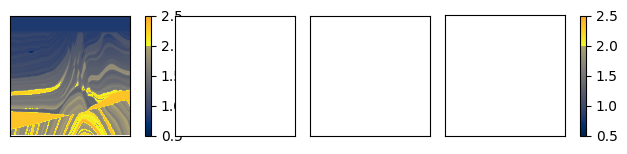

In [84]:
sc=0
fig = plt.figure(figsize=(6, 1.5))

# Positions: [left, bottom, width, height]
# Very tight layout, no big gaps
positions = [
    [0.00,  0.0, 0.2,   1.0],  # 1 - square
    [0.225, 0.1, 0.01,  0.8],  # 2 - colorbar
    [0.275, 0.0, 0.20,  1.0],  # 3 - square
    [0.5,   0.0, 0.20,  1.0],  # 4 - square
    [0.725, 0.0, 0.20,  1.0],  # 5 - square
    [0.95,  0.1, 0.01,  0.8],  # 6 - colorbar
]

ax = []
for i, pos in enumerate(positions, start=1):
    a = fig.add_axes(pos)
    # a.set_title(f"Ax {i}", fontsize=8)
    ax.append(a)

# plot
norm = mpl.colors.Normalize(vmin=0.5, vmax=2.5)
ax[0].imshow(data[sc]['alpha'][::-1], norm=norm, cmap = twocolorsmap) 

# cbar 
sm = ScalarMappable(norm=norm, cmap=twocolorsmap)
sm.set_array([])  # Dummy data to satisfy colorbar
cbar = fig.colorbar(sm, cax=ax[1], orientation='vertical', shrink=0.6)
cbar.set_ticks([0.5,1.0,1.5,2.0,2.5], labels=[0.5,1.0,1.5,2.0,2.5])
cbar = fig.colorbar(sm, cax=ax[-1], orientation='vertical', shrink=0.6)
cbar.set_ticks([0.5,1.0,1.5,2.0,2.5], labels=[0.5,1.0,1.5,2.0,2.5])

    #########################################################################################

    # for size,color in zip([50,30,10], ["black", "white", "black"]): 
    #     ax[0].scatter(250,250, s=size, marker='o', color =color)
    #     ax[0].scatter(250,750, s=size, marker='o', color =color)
    #     ax[0].scatter(750,250, s=size, marker='o', color =color)
    #     ax[0].scatter(750,750, s=size, marker='o', color =color)

    #     ax[1].scatter(470,1000-360, s=size, marker='o', color =color)
    #     ax[1].scatter(720,1000-630, s=size, marker='o', color =color)

    #     ax[2].scatter(630,1000-370, s=size, marker='o', color =color)
    #     ax[2].scatter(500,1000-167, s=size, marker='o', color =color)
    #     ax[2].scatter(650,1000-100, s=size, marker='o', color =color)
    #     ax[2].scatter(800,1000-550, s=size, marker='o', color =color)
    #     ax[2].scatter(200,1000-360, s=size, marker='o', color =color)
        
for i in [0,2,3,4]: 
    ax[i].set_xticks([]) 
    ax[i].set_yticks([]) 
    ax[i].set_aspect("equal")
